In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# cleaned dataset
df = pd.read_csv('dataset/depression_dataset_reddit_cleaned.csv')
print(df.shape)
df.head()

(7731, 2)


,clean_text,is_depression
0,we understand that most people who reply immed...,1
1,welcome to r depression s check in post a plac...,1
2,anyone else instead of sleeping more when depr...,1
3,i ve kind of stuffed around a lot in my life d...,1
4,sleep is my greatest and most comforting escap...,1


TEXT PROCESSING

In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tokenize.treebank import TreebankWordDetokenizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

import spacy
import nltk

nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 108.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
nlp = spacy.load("en_core_web_sm")

# stop words
stop_words = set(stopwords.words('english'))

# total rows (untuk loop)
count_row = df.shape[0]

# container cleaned words
all_cleaned_words = []

for i in range(count_row):
    # tokenize text
    sentence_token = word_tokenize(df.clean_text[i])

    # remove stop words
    filtered_words = [word for word in sentence_token if word.lower() not in stop_words and word.isalpha()]

    # lemmatize withspaCy
    doc = nlp(" ".join(filtered_words))
    lemmatized_words = [token.lemma_.lower() for token in doc if token.lemma_ != '-PRON-']

    # update df.clean_text with lemmatized sentence
    df.at[i, 'clean_text'] = TreebankWordDetokenizer().detokenize(lemmatized_words)

    # collect cleaned words for frequency count
    all_cleaned_words.extend(lemmatized_words)

# count word frequencies
word_counts = Counter(all_cleaned_words)

# create dataframe of word frequencies
word_freq_df = (pd.DataFrame(word_counts.items(), columns=['word', 'frequency']).sort_values(by='frequency', ascending=False).reset_index(drop=True))

In [ ]:
# df.head()
word_freq_df.head()

,word,frequency
0,feel,4270
1,get,3828
2,wa,3810
3,like,3635
4,go,3405


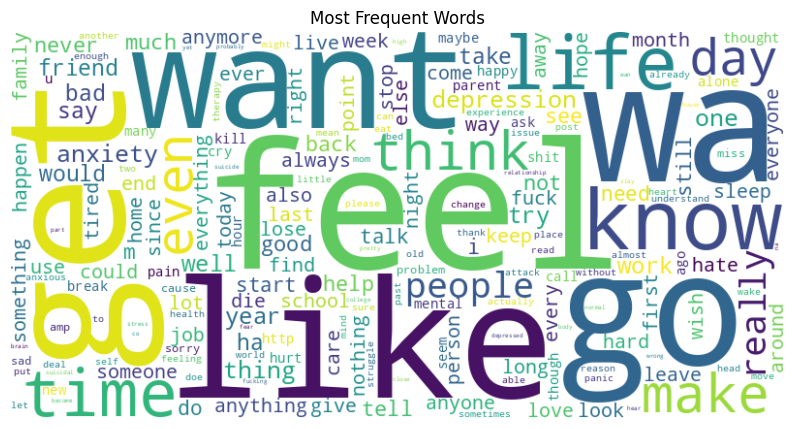

In [ ]:
# visualize
wordcloud = WordCloud(stopwords=stop_words, width=800, height=400, max_words=200, background_color='white', colormap='viridis').generate_from_frequencies(dict(zip(word_freq_df['word'], word_freq_df['frequency'])))

# plot
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words', fontsize=12)
plt.show()

Text Vectorization

In [ ]:
# TF IDF
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns

In [ ]:
tf_idf_extractor = TfidfVectorizer()
tf_idf_feature = tf_idf_extractor.fit_transform(df['clean_text'])

In [ ]:
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1,2), stop_words='english')

# fit model
tfidf_matrix = vectorizer.fit_transform(df['clean_text'])

# convert to DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

tfidf_df.head()

,able,absolutely,abuse,abusive,accept,accident,account,act,action,actually,...,www,yeah,year,year ago,year old,year wa,yes,yesterday,young,zoloft
0,0.036732,0.0,0.047205,0.0,0.094628,0.0,0.104457,0.044779,0.0,0.0,...,0.0,0.0,0.026901,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# get top mean TF-IDF
mean_tfidf = tfidf_df.mean().sort_values(ascending=False).head(20)

print(mean_tfidf)

depression    0.043816
feel          0.039358
like          0.034526
wa            0.033723
want          0.030565
work          0.027524
know          0.026315
day           0.024803
think         0.023283
time          0.022566
make          0.021282
life          0.020822
anxiety       0.019766
really        0.019652
people        0.018579
ha            0.018426
sleep         0.017447
need          0.017446
bad           0.017344
good          0.016880
dtype: float64


/tmp/ipython-input-866659752.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_tfidf.values, y=mean_tfidf.index,palette='viridis')


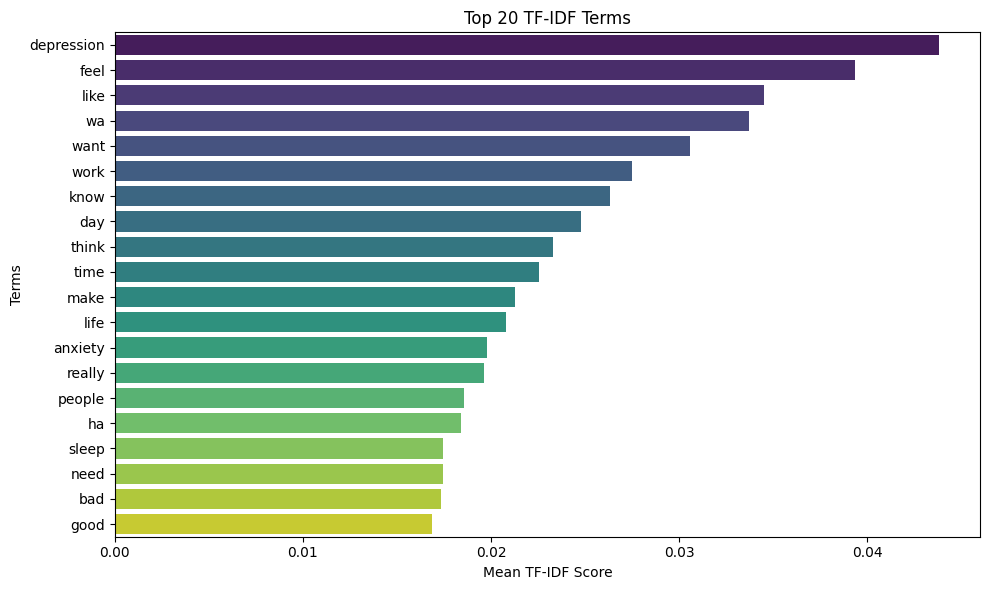

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=mean_tfidf.values, y=mean_tfidf.index,palette='viridis')

plt.title('Top 20 TF-IDF Terms')
plt.xlabel('Mean TF-IDF Score')
plt.ylabel('Terms')
plt.tight_layout()
plt.show()

MODELLING

In [ ]:
# Naive Baiyes Method
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# split data
X_train, X_test, y_train, y_test = train_test_split(df['clean_text'], df['is_depression'], test_size=0.2, random_state=42)

# vectorize dengan TF-IDF (bisa menggunakan yang sebelumnya)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
# fit model NB
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [ ]:
y_pred = nb_model.predict(X_test_tfidf)

In [ ]:
# evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Accuracy: 0.9017453135100194

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.85      0.90       783
           1       0.86      0.96      0.91       764

    accuracy                           0.90      1547
   macro avg       0.91      0.90      0.90      1547
weighted avg       0.91      0.90      0.90      1547



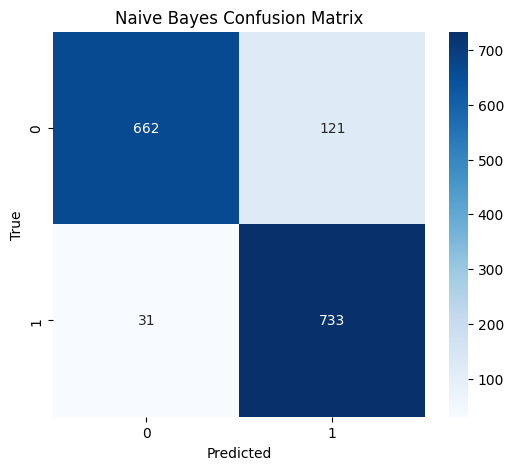

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nb_model.classes_, yticklabels=nb_model.classes_)
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
# save model
import pickle

In [ ]:
# model
with open("nb_model.pkl", "wb") as f:
    pickle.dump(nb_model, f)

# vectorizer
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)